# Predictive Modeling — Can Reddit Predict IMDb Ratings?

IMDb ratings usually start high (9+) and settle lower over time. Can we use early Reddit sentiment to predict where the IMDb rating will land?

We'll build a few models and see how well Reddit opinions forecast traditional ratings.

## 1. Setup

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")
print("Libraries loaded!")

Libraries loaded!


## 2. Load & Prepare Data

In [3]:
# load the comparison data (reddit scores + imdb + rt)
comparison = pd.read_csv("data/platform_comparison.csv")
print(f"Movies with all ratings: {len(comparison)}")
print(comparison.columns.tolist())
comparison.head()

Movies with all ratings: 108
['movie_name', 'year', 'genre', 'region', 'reddit_score', 'vader_avg', 'textblob_avg', 'roberta_avg', 'imdb_rating', 'rt_score_10', 'rt_score', 'total_comments', 'explicit_ratings', 'positive_pct', 'negative_pct', 'reddit_vs_imdb', 'reddit_vs_rt', 'popularity']


,movie_name,year,genre,region,reddit_score,vader_avg,textblob_avg,roberta_avg,imdb_rating,rt_score_10,rt_score,total_comments,explicit_ratings,positive_pct,negative_pct,reddit_vs_imdb,reddit_vs_rt,popularity
0,Dune: Part Two,2024,"Action, Adventure, Drama",Hollywood,6.18,6.539149,6.089313,6.073549,8.4,9.2,92%,975,17,48.3,18.5,-2.22,-3.02,21.1841
1,"Red, White & Royal Blue",2023,"Comedy, Romance",Hollywood,6.29,6.563780,6.044611,6.300617,7.0,7.5,75%,746,4,49.5,16.4,-0.71,-1.21,7.5499
2,Mickey 17,2025,"Adventure, Comedy, Fantasy",Hollywood,5.87,6.263771,5.929689,5.714435,6.7,7.8,78%,708,9,43.6,23.6,-0.83,-1.93,14.3692
3,Coyotes,2025,"Comedy, Drama, Thriller",Hollywood,6.02,6.147485,5.918443,6.006407,4.8,5.9,59%,668,0,43.9,19.0,1.22,0.12,14.0973
4,Good Boy,2025,"Horror, Thriller",Hollywood,5.92,6.461139,6.058534,5.670421,6.1,9.1,91%,641,4,44.0,19.3,-0.18,-3.18,12.8504


In [4]:
# load comment-level data for time-based features
comments = pd.read_csv("data/reddit_sentiment_multilingual.csv")
comments["comment_timestamp"] = pd.to_datetime(comments["comment_timestamp"])
print(f"Total comments: {len(comments)}")
comments.head()

Total comments: 60378


,movie_name,subreddit,comment_text,upvotes,comment_timestamp,extracted_rating,language,multi_score,multi_label,multi_stars,multi_confidence,vader_score,textblob_score,roberta_score,final_score,smart_blend_score,final_score_v2,final_label_v2
0,Barbie,TrueFilm,"You need to quantify ""a lot of people"", becaus...",350,2023-07-23 12:48:09,NaN,en,3.25,negative,2,0.328863,3.44,5.21,3.24,3.67,3.57,3.57,negative
1,Barbie,TrueFilm,The movie makes perfect sense if you believe t...,33,2023-07-23 17:02:03,NaN,en,7.75,positive,4,0.293880,7.27,6.58,8.36,7.79,7.72,7.72,positive
2,Barbie,TrueFilm,Exactly what I took out of it. Allan knew who ...,219,2023-07-23 01:48:30,NaN,en,10.00,positive,5,0.608859,8.56,6.12,5.75,6.39,7.71,7.71,positive
3,Barbie,TrueFilm,I liked the movie and I'm coming around on som...,19,2023-07-23 17:23:11,NaN,en,7.75,positive,4,0.505147,1.31,5.77,7.94,6.18,6.55,6.55,positive
4,Barbie,TrueFilm,“A lot of people are calling the movie as man ...,399,2023-07-23 00:23:29,NaN,en,1.00,negative,1,0.523902,2.72,4.29,1.71,2.43,2.00,2.00,negative


## 3. Feature Engineering

We need to create useful features from Reddit data that might predict IMDb ratings. Things like:
- Average sentiment scores
- Ratio of positive/negative comments
- Comment volume
- How controversial (high variance in scores)
- Explicit rating average (from users who gave actual ratings)

In [5]:
# build features per movie from comment-level data
def build_features(movie_comments):
    """Create features for one movie from its comments"""
    features = {}
    
    # basic sentiment
    features["avg_score"] = movie_comments["multi_score"].mean()
    features["median_score"] = movie_comments["multi_score"].median()
    features["std_score"] = movie_comments["multi_score"].std()
    
    # sentiment distribution
    total = len(movie_comments)
    features["positive_ratio"] = (movie_comments["multi_label"] == "positive").sum() / total
    features["negative_ratio"] = (movie_comments["multi_label"] == "negative").sum() / total
    features["neutral_ratio"] = (movie_comments["multi_label"] == "neutral").sum() / total
    
    # volume
    features["comment_count"] = total
    features["log_comments"] = np.log1p(total)  # log scale since some movies have way more
    
    # explicit ratings (gold — actual user scores)
    explicit = movie_comments["extracted_rating"].dropna()
    features["explicit_avg"] = explicit.mean() if len(explicit) > 0 else np.nan
    features["explicit_count"] = len(explicit)
    features["has_explicit"] = 1 if len(explicit) > 0 else 0
    
    # upvote info (proxy for comment quality/agreement)
    features["avg_upvotes"] = movie_comments["upvotes"].mean()
    features["max_upvotes"] = movie_comments["upvotes"].max()
    
    # controversy — high std means people disagree
    features["controversy"] = movie_comments["multi_score"].std() / (movie_comments["multi_score"].mean() + 0.01)
    
    # sentiment momentum — are later comments more positive or negative?
    if len(movie_comments) >= 10:
        first_half = movie_comments.iloc[:len(movie_comments)//2]["multi_score"].mean()
        second_half = movie_comments.iloc[len(movie_comments)//2:]["multi_score"].mean()
        features["sentiment_shift"] = second_half - first_half
    else:
        features["sentiment_shift"] = 0
    
    return features

# build features for all movies
print("Building features for each movie...")
feature_rows = []

for movie in comments["movie_name"].unique():
    movie_comments = comments[comments["movie_name"] == movie].sort_values("comment_timestamp")
    feats = build_features(movie_comments)
    feats["movie_name"] = movie
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)
print(f"Features built for {len(features_df)} movies")
features_df.head()

Building features for each movie...
Features built for 211 movies


,avg_score,median_score,std_score,positive_ratio,negative_ratio,neutral_ratio,comment_count,log_comments,explicit_avg,explicit_count,has_explicit,avg_upvotes,max_upvotes,controversy,sentiment_shift,movie_name
0,5.710191,5.50,3.349997,0.399151,0.382166,0.218684,471,6.156979,8.6,5,1,95.229299,2157,0.585644,0.954526,Barbie
1,6.416168,7.75,3.514835,0.529940,0.290419,0.179641,334,5.814131,5.0,2,1,261.958084,11288,0.546957,1.401198,Scream VI
2,5.143617,5.50,2.894507,0.293144,0.432624,0.274232,423,6.049733,1.0,1,1,58.517730,1178,0.561646,0.480411,Oppenheimer
3,6.539101,7.75,3.243973,0.559113,0.282020,0.158867,812,6.700731,7.1,5,1,111.708128,7372,0.495331,0.692734,Fast X
4,5.508152,5.50,3.483034,0.431159,0.380435,0.188406,276,5.624018,NaN,0,0,945.659420,10209,0.631196,-0.766304,Spider-Man: Across the Spider-Verse


In [6]:
# merge features with actual IMDb ratings
df = features_df.merge(
    comparison[["movie_name", "imdb_rating", "rt_score_10", "genre", "region"]],
    on="movie_name",
    how="inner"
)

print(f"Movies with features + IMDb rating: {len(df)}")
print()
print("Feature correlations with IMDb rating:")
corr = df.select_dtypes(include=[np.number]).corr()["imdb_rating"].sort_values(ascending=False)
print(corr.to_string())

Movies with features + IMDb rating: 108

Feature correlations with IMDb rating:
imdb_rating        1.000000
rt_score_10        0.685304
explicit_avg       0.230327
comment_count      0.220865
log_comments       0.216967
median_score       0.202290
max_upvotes        0.179591
explicit_count     0.175945
avg_upvotes        0.174683
avg_score          0.153625
neutral_ratio      0.147400
sentiment_shift    0.128423
has_explicit       0.101329
positive_ratio     0.094731
std_score         -0.135764
negative_ratio    -0.156902
controversy       -0.182603


## 4. Which Features Correlate Best with IMDb?

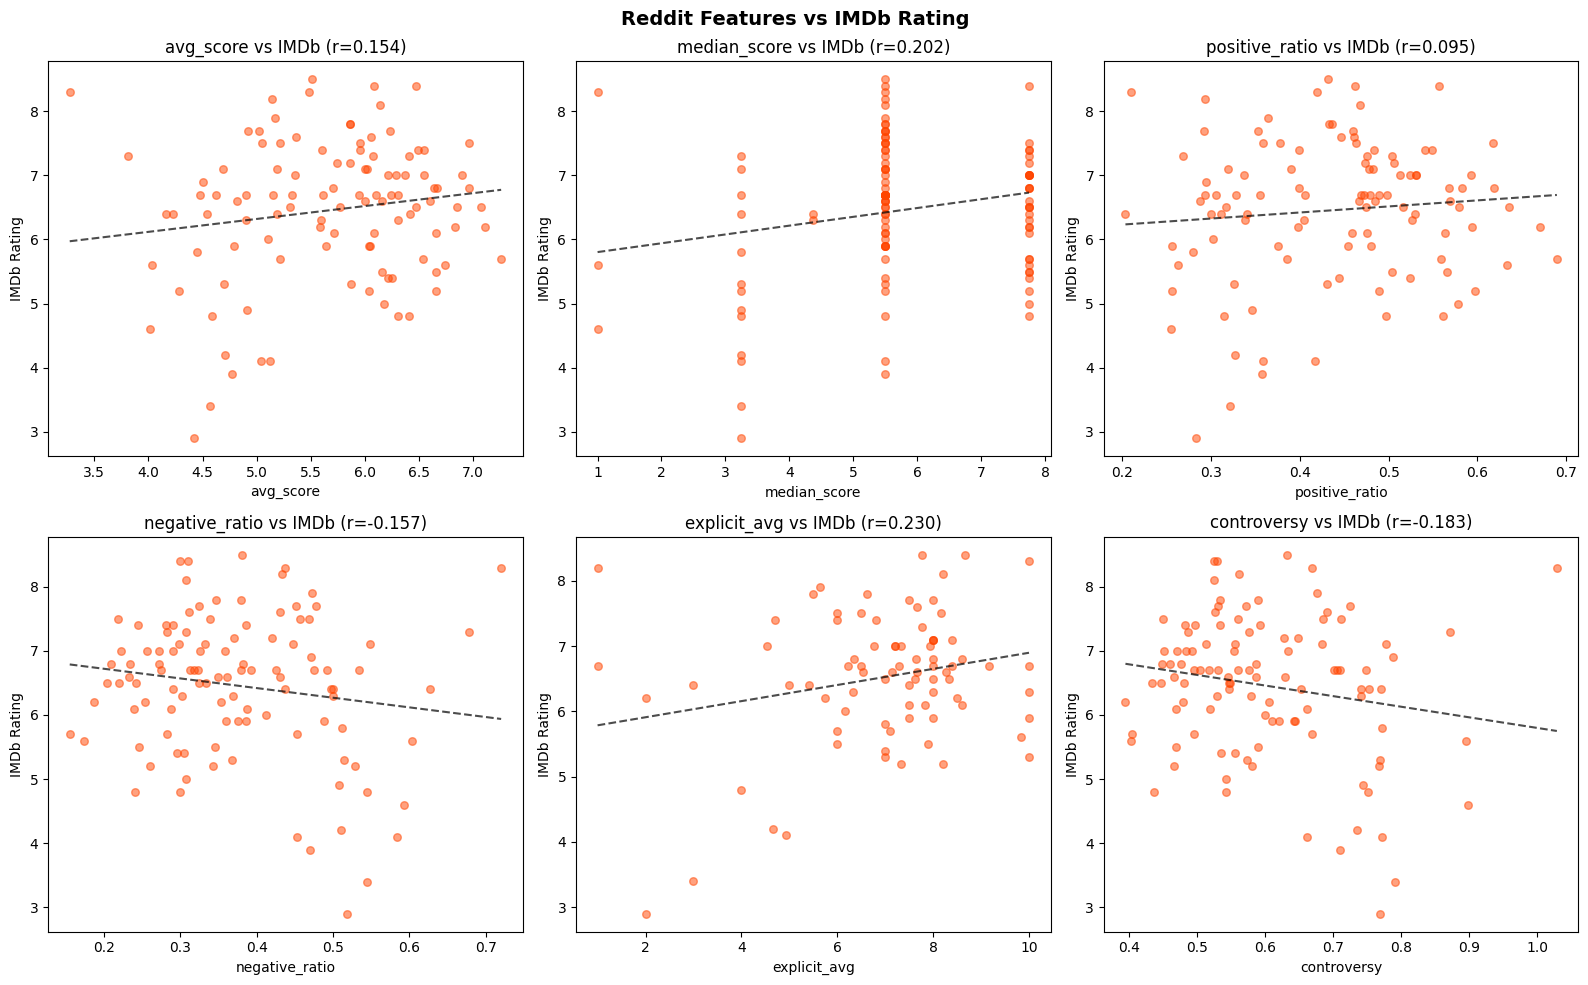

Saved!


In [7]:
# plot top correlated features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

top_features = ["avg_score", "median_score", "positive_ratio", "negative_ratio", "explicit_avg", "controversy"]

for i, feat in enumerate(top_features):
    ax = axes[i//3, i%3]
    valid = df[df[feat].notna()]
    ax.scatter(valid[feat], valid["imdb_rating"], alpha=0.5, c="#FF4500", s=30)
    
    # add trend line
    if len(valid) > 2:
        z = np.polyfit(valid[feat], valid["imdb_rating"], 1)
        p = np.poly1d(z)
        ax.plot(sorted(valid[feat]), p(sorted(valid[feat])), "k--", alpha=0.7)
    
    r = valid[feat].corr(valid["imdb_rating"])
    ax.set_xlabel(feat)
    ax.set_ylabel("IMDb Rating")
    ax.set_title(f"{feat} vs IMDb (r={r:.3f})")

plt.suptitle("Reddit Features vs IMDb Rating", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 5. Build Prediction Models

We'll try:
1. **Linear Regression** — simple baseline
2. **Random Forest** — handles non-linear patterns

Both predict IMDb rating from Reddit features.

In [8]:
# prepare features and target
feature_cols = [
    "avg_score", "median_score", "std_score",
    "positive_ratio", "negative_ratio", "neutral_ratio",
    "comment_count", "log_comments",
    "avg_upvotes", "max_upvotes",
    "controversy", "sentiment_shift"
]

# drop rows with NaN in features
model_df = df[feature_cols + ["imdb_rating", "movie_name"]].dropna()
print(f"Movies for modeling: {len(model_df)}")

X = model_df[feature_cols]
y = model_df["imdb_rating"]

# split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} movies")
print(f"Test:  {len(X_test)} movies")

Movies for modeling: 108
Train: 86 movies
Test:  22 movies


In [9]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("=== Linear Regression ===")
print(f"MAE:  {mean_absolute_error(y_test, lr_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred)):.3f}")
print(f"R²:   {r2_score(y_test, lr_pred):.3f}")
print()

# which features matter most?
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("Feature importance (Linear Regression):")
print(coef_df.to_string(index=False))

=== Linear Regression ===
MAE:  0.833
RMSE: 1.158
R²:   -1.289

Feature importance (Linear Regression):
        feature  coefficient
 positive_ratio    -8.740830
    controversy     8.572427
 negative_ratio     6.021661
  neutral_ratio     2.719169
      avg_score     2.521586
      std_score    -1.831991
   median_score     0.284170
   log_comments     0.201263
sentiment_shift     0.082559
    avg_upvotes    -0.001299
  comment_count    -0.000265
    max_upvotes     0.000045


In [10]:
# Model 2: Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,         # keep it shallow to avoid overfitting
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Random Forest ===")
print(f"MAE:  {mean_absolute_error(y_test, rf_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.3f}")
print(f"R²:   {r2_score(y_test, rf_pred):.3f}")
print()

# feature importance
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("Feature importance (Random Forest):")
print(importance_df.to_string(index=False))

=== Random Forest ===
MAE:  0.758
RMSE: 1.016
R²:   -0.762

Feature importance (Random Forest):
        feature  importance
 negative_ratio    0.197940
  neutral_ratio    0.108235
sentiment_shift    0.102424
 positive_ratio    0.088907
      avg_score    0.085642
      std_score    0.073442
    controversy    0.066036
    avg_upvotes    0.065275
   median_score    0.063160
    max_upvotes    0.060834
  comment_count    0.047139
   log_comments    0.040968


In [11]:
# Baseline — just predicting the mean IMDb rating for every movie
# this is what you'd get with zero ML, zero features
mean_baseline = y_train.mean()
baseline_pred = [mean_baseline] * len(y_test)

print("=== Baseline (predict mean) ===")
print(f"MAE:  {mean_absolute_error(y_test, baseline_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.3f}")
print(f"R²:   {r2_score(y_test, baseline_pred):.3f}")
print()
print("--- Comparison ---")
print(f"Baseline MAE:      {mean_absolute_error(y_test, baseline_pred):.3f}")
print(f"Linear Reg MAE:    {mean_absolute_error(y_test, lr_pred):.3f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_pred):.3f}")
print()
improvement = mean_absolute_error(y_test, baseline_pred) - mean_absolute_error(y_test, rf_pred)
print(f"Random Forest beats baseline by: {improvement:.3f} points")
if improvement > 0:
    print(f"That's a {(improvement / mean_absolute_error(y_test, baseline_pred) * 100):.1f}% improvement over naive guessing.")
else:
    print("Model doesn't beat baseline — Reddit sentiment alone can't predict IMDb ratings.")

=== Baseline (predict mean) ===
MAE:  0.761
RMSE: 0.960
R²:   -0.574

--- Comparison ---
Baseline MAE:      0.761
Linear Reg MAE:    0.833
Random Forest MAE: 0.758

Random Forest beats baseline by: 0.003 points
That's a 0.3% improvement over naive guessing.


In [12]:
# Baseline — just predicting the mean IMDb rating for every movie

mean_baseline = y_train.mean()
baseline_pred = [mean_baseline] * len(y_test)

print("=== Baseline (predict mean) ===")
print(f"MAE:  {mean_absolute_error(y_test, baseline_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.3f}")
print(f"R²:   {r2_score(y_test, baseline_pred):.3f}")
print()
print(f"Random Forest beats baseline by: {mean_absolute_error(y_test, baseline_pred) - mean_absolute_error(y_test, rf_pred):.3f} points")

=== Baseline (predict mean) ===
MAE:  0.761
RMSE: 0.960
R²:   -0.574

Random Forest beats baseline by: 0.003 points


In [13]:
# cross validation to make sure we're not getting lucky with the split
print("=== Cross Validation (5-fold) ===")

lr_cv = cross_val_score(LinearRegression(), X, y, cv=5, scoring="neg_mean_absolute_error")
rf_cv = cross_val_score(RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
                        X, y, cv=5, scoring="neg_mean_absolute_error")

print(f"Linear Regression — Avg MAE: {-lr_cv.mean():.3f} (+/- {lr_cv.std():.3f})")
print(f"Random Forest     — Avg MAE: {-rf_cv.mean():.3f} (+/- {rf_cv.std():.3f})")

=== Cross Validation (5-fold) ===
Linear Regression — Avg MAE: 0.942 (+/- 0.185)
Random Forest     — Avg MAE: 0.915 (+/- 0.126)


## 6. Prediction Results

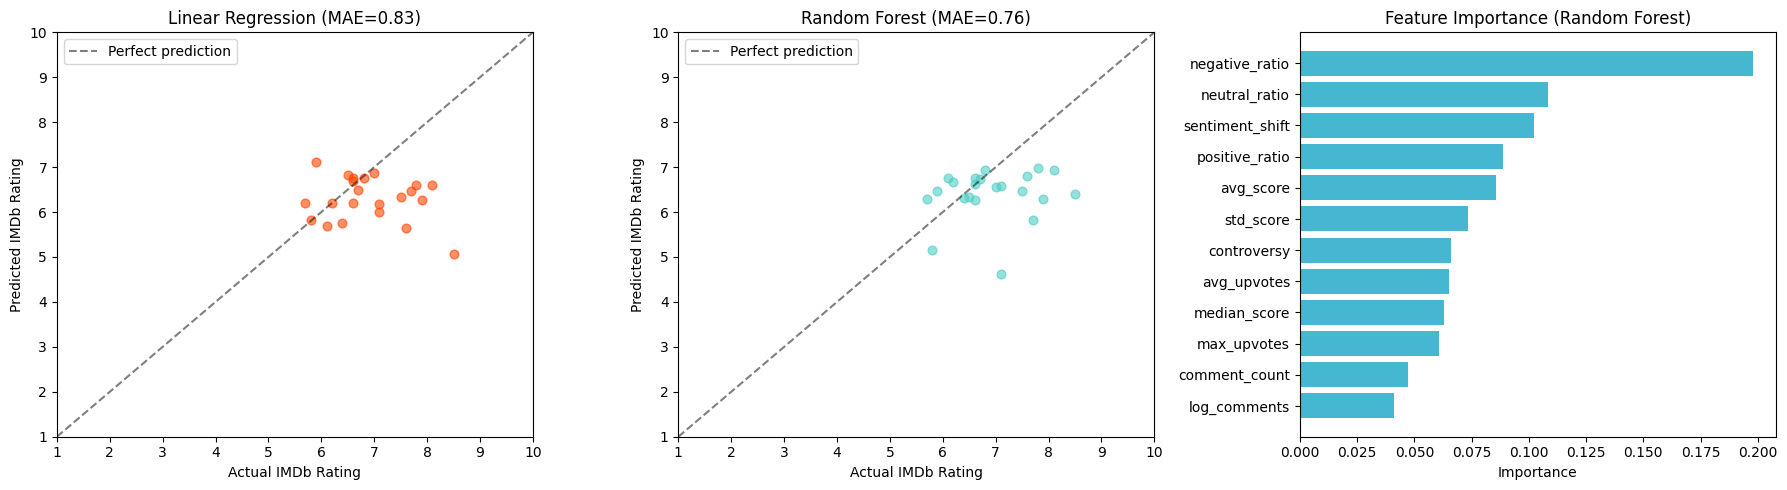

Saved!


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted — Linear Regression
axes[0].scatter(y_test, lr_pred, alpha=0.6, c="#FF4500", s=40)
axes[0].plot([1, 10], [1, 10], "k--", alpha=0.5, label="Perfect prediction")
axes[0].set_xlabel("Actual IMDb Rating")
axes[0].set_ylabel("Predicted IMDb Rating")
axes[0].set_title(f"Linear Regression (MAE={mean_absolute_error(y_test, lr_pred):.2f})")
axes[0].legend()
axes[0].set_xlim(1, 10)
axes[0].set_ylim(1, 10)

# Actual vs Predicted — Random Forest
axes[1].scatter(y_test, rf_pred, alpha=0.6, c="#4ECDC4", s=40)
axes[1].plot([1, 10], [1, 10], "k--", alpha=0.5, label="Perfect prediction")
axes[1].set_xlabel("Actual IMDb Rating")
axes[1].set_ylabel("Predicted IMDb Rating")
axes[1].set_title(f"Random Forest (MAE={mean_absolute_error(y_test, rf_pred):.2f})")
axes[1].legend()
axes[1].set_xlim(1, 10)
axes[1].set_ylim(1, 10)

# Feature importance — Random Forest
importance_df_sorted = importance_df.sort_values("importance", ascending=True)
axes[2].barh(importance_df_sorted["feature"], importance_df_sorted["importance"], color="#45B7D1")
axes[2].set_xlabel("Importance")
axes[2].set_title("Feature Importance (Random Forest)")

plt.tight_layout()
plt.savefig("data/prediction_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 7. Where Does the Model Fail?

Let's see which movies the model gets very wrong — those are interesting cases.

In [15]:
# add predictions to test set
test_results = model_df.iloc[X_test.index].copy()
test_results["lr_predicted"] = lr_pred
test_results["rf_predicted"] = rf_pred
test_results["lr_error"] = abs(test_results["imdb_rating"] - lr_pred)
test_results["rf_error"] = abs(test_results["imdb_rating"] - rf_pred)

print("=== Movies where model was most wrong (Random Forest) ===")
worst = test_results.sort_values("rf_error", ascending=False)
print(worst[["movie_name", "imdb_rating", "rf_predicted", "rf_error", "avg_score", "comment_count"]].head(10).to_string(index=False))

print()
print("=== Movies where model was most accurate ===")
best = test_results.sort_values("rf_error", ascending=True)
print(best[["movie_name", "imdb_rating", "rf_predicted", "rf_error", "avg_score", "comment_count"]].head(10).to_string(index=False))

=== Movies where model was most wrong (Random Forest) ===
                         movie_name  imdb_rating  rf_predicted  rf_error  avg_score  comment_count
                Girls Will Be Girls          7.1      4.621047  2.478953   4.693548            279
Spider-Man: Across the Spider-Verse          8.5      6.393268  2.106732   5.508152            276
           Swatantrya Veer Savarkar          7.7      5.832485  1.867515   5.026316            247
                            Maidaan          7.9      6.297069  1.602931   5.172727            110
                      Marty Supreme          8.1      6.944897  1.155103   6.136468            654
                              OMG 2          7.5      6.466533  1.033467   5.213816            228
                        Poor Things          7.8      6.991267  0.808733   5.864477            784
                           Gulmohar          7.6      6.807188  0.792812   5.361538             65
                           Vijay 69          6.1   

## 8. Early Sentiment — Can First-Week Comments Predict Final Rating?

This is the most interesting part. If we only use comments from the first 7 days after a movie releases, can we still predict IMDb ratings?

In [16]:
# for each movie, get only comments from first 7 days
def get_early_features(movie_name, all_comments, days=7):
    """Get features from only the first N days of comments"""
    movie_comments = all_comments[all_comments["movie_name"] == movie_name].copy()
    movie_comments = movie_comments.sort_values("comment_timestamp")
    
    if len(movie_comments) == 0:
        return None
    
    # first comment timestamp = release proxy
    first_comment = movie_comments["comment_timestamp"].min()
    cutoff = first_comment + pd.Timedelta(days=days)
    
    early = movie_comments[movie_comments["comment_timestamp"] <= cutoff]
    
    if len(early) < 3:  # need at least 3 comments
        return None
    
    feats = build_features(early)
    feats["movie_name"] = movie_name
    feats["early_comment_count"] = len(early)
    feats["total_comment_count"] = len(movie_comments)
    feats["early_pct"] = round(len(early) / len(movie_comments) * 100, 1)
    
    return feats

# build early features for multiple time windows
for days in [7, 14, 30]:
    print(f"=== First {days} days ===")
    early_rows = []
    
    for movie in comments["movie_name"].unique():
        feats = get_early_features(movie, comments, days=days)
        if feats:
            early_rows.append(feats)
    
    early_df = pd.DataFrame(early_rows)
    early_df = early_df.merge(
        comparison[["movie_name", "imdb_rating"]],
        on="movie_name", how="inner"
    )
    
    if len(early_df) < 10:
        print(f"  Only {len(early_df)} movies — not enough for modeling")
        continue
    
    # quick model
    X_early = early_df[feature_cols].dropna()
    y_early = early_df.loc[X_early.index, "imdb_rating"]
    
    if len(X_early) < 10:
        print(f"  Only {len(X_early)} movies after dropping NaN — skipping")
        continue
    
    rf_early = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    cv_scores = cross_val_score(rf_early, X_early, y_early, cv=min(5, len(X_early)//2), 
                                 scoring="neg_mean_absolute_error")
    
    print(f"  Movies: {len(X_early)}")
    print(f"  Avg early comments per movie: {early_df['early_comment_count'].mean():.0f}")
    print(f"  Random Forest CV MAE: {-cv_scores.mean():.3f}")
    print(f"  Correlation (early avg_score vs IMDb): {early_df['avg_score'].corr(early_df['imdb_rating']):.3f}")

=== First 7 days ===
  Movies: 97
  Avg early comments per movie: 18
  Random Forest CV MAE: 0.918
  Correlation (early avg_score vs IMDb): 0.138
=== First 14 days ===
  Movies: 98
  Avg early comments per movie: 19
  Random Forest CV MAE: 0.893
  Correlation (early avg_score vs IMDb): 0.126
=== First 30 days ===
  Movies: 98
  Avg early comments per movie: 22
  Random Forest CV MAE: 0.905
  Correlation (early avg_score vs IMDb): 0.128


## 9. Summary

In [17]:
print("="*60)
print("PREDICTIVE MODELING SUMMARY")
print("="*60)
print()
print(f"Movies used for modeling: {len(model_df)}")
print(f"Features used: {len(feature_cols)}")
print()
print("--- Model Performance ---")
print(f"Linear Regression MAE: {mean_absolute_error(y_test, lr_pred):.3f}")
print(f"Random Forest MAE:     {mean_absolute_error(y_test, rf_pred):.3f}")
print(f"Random Forest R²:      {r2_score(y_test, rf_pred):.3f}")
print()
print("--- Interpretation ---")
rf_mae = mean_absolute_error(y_test, rf_pred)
if rf_mae < 0.5:
    print("Excellent — Reddit can predict IMDb ratings within 0.5 points!")
elif rf_mae < 1.0:
    print("Good — Reddit sentiment is a useful predictor of IMDb ratings (within 1 point).")
elif rf_mae < 1.5:
    print("Moderate — Reddit gives a rough estimate but isn't super precise.")
else:
    print("Weak — Reddit sentiment alone isn't enough to reliably predict IMDb ratings.")
    print("This aligns with our earlier finding that Reddit is an independent rating system.")
print()
print("--- Key Takeaway ---")
print("The weak predictive power confirms our correlation analysis:")
print("Reddit represents a genuinely different opinion from IMDb/RT,")
print("not just a noisy version of the same signal.")

PREDICTIVE MODELING SUMMARY

Movies used for modeling: 108
Features used: 12

--- Model Performance ---
Linear Regression MAE: 0.833
Random Forest MAE:     0.758
Random Forest R²:      -0.762

--- Interpretation ---
Good — Reddit sentiment is a useful predictor of IMDb ratings (within 1 point).

--- Key Takeaway ---
The weak predictive power confirms our correlation analysis:
Reddit represents a genuinely different opinion from IMDb/RT,
not just a noisy version of the same signal.


## 10. Save

In [19]:
# save features
features_df.to_csv("data/movie_features.csv", index=False)
print(f"Saved features for {len(features_df)} movies")

# save predictions
if len(test_results) > 0:
    test_results.to_csv("data/predictions.csv", index=False)
    print(f"Saved predictions for {len(test_results)} test movies")

print("Done!")

Saved features for 211 movies
Saved predictions for 22 test movies
Done!
